In [13]:
from pydoc import text

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [14]:
datafake = pd.read_csv("WELFake_Dataset.csv")
datafake

,Unnamed: 0,title,text,label
0,0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...,1
1,1,NaN,Did they post their votes for Hillary already?,1
2,2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,"Now, most of the demonstrators gathered last ...",1
3,3,"Bobby Jindal, raised Hindu, uses story of Chri...",A dozen politically active pastors came here f...,0
4,4,SATAN 2: Russia unvelis an image of its terrif...,"The RS-28 Sarmat missile, dubbed Satan 2, will...",1
...,...,...,...,...
72129,72129,Russians steal research on Trump in hack of U....,WASHINGTON (Reuters) - Hackers believed to be ...,0
72130,72130,WATCH: Giuliani Demands That Democrats Apolog...,"You know, because in fantasyland Republicans n...",1
72131,72131,Migrants Refuse To Leave Train At Refugee Camp...,Migrants Refuse To Leave Train At Refugee Camp...,0
72132,72132,Trump tussle gives unpopular Mexican leader mu...,MEXICO CITY (Reuters) - Donald Trump’s combati...,0


In [15]:
datacat = pd.read_json("News_Category_Dataset_v3.json", lines=True)
datacat

,link,headline,category,short_description,authors,date
0,https://www.huffpost.com/entry/covid-boosters-...,Over 4 Million Americans Roll Up Sleeves For O...,U.S. NEWS,Health experts said it is too early to predict...,"Carla K. Johnson, AP",2022-09-23
1,https://www.huffpost.com/entry/american-airlin...,"American Airlines Flyer Charged, Banned For Li...",U.S. NEWS,He was subdued by passengers and crew when he ...,Mary Papenfuss,2022-09-23
2,https://www.huffpost.com/entry/funniest-tweets...,23 Of The Funniest Tweets About Cats And Dogs ...,COMEDY,"""Until you have a dog you don't understand wha...",Elyse Wanshel,2022-09-23
3,https://www.huffpost.com/entry/funniest-parent...,The Funniest Tweets From Parents This Week (Se...,PARENTING,"""Accidentally put grown-up toothpaste on my to...",Caroline Bologna,2022-09-23
4,https://www.huffpost.com/entry/amy-cooper-lose...,Woman Who Called Cops On Black Bird-Watcher Lo...,U.S. NEWS,Amy Cooper accused investment firm Franklin Te...,Nina Golgowski,2022-09-22
...,...,...,...,...,...,...
209522,https://www.huffingtonpost.com/entry/rim-ceo-t...,RIM CEO Thorsten Heins' 'Significant' Plans Fo...,TECH,Verizon Wireless and AT&T are already promotin...,"Reuters, Reuters",2012-01-28
209523,https://www.huffingtonpost.com/entry/maria-sha...,Maria Sharapova Stunned By Victoria Azarenka I...,SPORTS,"Afterward, Azarenka, more effusive with the pr...",,2012-01-28
209524,https://www.huffingtonpost.com/entry/super-bow...,"Giants Over Patriots, Jets Over Colts Among M...",SPORTS,"Leading up to Super Bowl XLVI, the most talked...",,2012-01-28
209525,https://www.huffingtonpost.com/entry/aldon-smi...,Aldon Smith Arrested: 49ers Linebacker Busted ...,SPORTS,CORRECTION: An earlier version of this story i...,,2012-01-28


## EDA для датасета про фейки

Дропнем лишний признак Unnamed

In [16]:
datafake = datafake.drop(columns=['Unnamed: 0'])
datafake

,title,text,label
0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...,1
1,NaN,Did they post their votes for Hillary already?,1
2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,"Now, most of the demonstrators gathered last ...",1
3,"Bobby Jindal, raised Hindu, uses story of Chri...",A dozen politically active pastors came here f...,0
4,SATAN 2: Russia unvelis an image of its terrif...,"The RS-28 Sarmat missile, dubbed Satan 2, will...",1
...,...,...,...
72129,Russians steal research on Trump in hack of U....,WASHINGTON (Reuters) - Hackers believed to be ...,0
72130,WATCH: Giuliani Demands That Democrats Apolog...,"You know, because in fantasyland Republicans n...",1
72131,Migrants Refuse To Leave Train At Refugee Camp...,Migrants Refuse To Leave Train At Refugee Camp...,0
72132,Trump tussle gives unpopular Mexican leader mu...,MEXICO CITY (Reuters) - Donald Trump’s combati...,0


Проверим пропуски

In [17]:
datafake.isna().sum()

title    558
text      39
label      0
dtype: int64

Новостей, где и текста и заголовка нету нет

In [18]:
datafake[datafake["title"].isna() & datafake["text"].isna()]

,title,text,label


Так как для любого объекта есть либо заголовок, либо текст, то заполним пропуски пустой штукой

In [19]:
datafake = datafake.fillna('')

datafake

,title,text,label
0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...,1
1,,Did they post their votes for Hillary already?,1
2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,"Now, most of the demonstrators gathered last ...",1
3,"Bobby Jindal, raised Hindu, uses story of Chri...",A dozen politically active pastors came here f...,0
4,SATAN 2: Russia unvelis an image of its terrif...,"The RS-28 Sarmat missile, dubbed Satan 2, will...",1
...,...,...,...
72129,Russians steal research on Trump in hack of U....,WASHINGTON (Reuters) - Hackers believed to be ...,0
72130,WATCH: Giuliani Demands That Democrats Apolog...,"You know, because in fantasyland Republicans n...",1
72131,Migrants Refuse To Leave Train At Refugee Camp...,Migrants Refuse To Leave Train At Refugee Camp...,0
72132,Trump tussle gives unpopular Mexican leader mu...,MEXICO CITY (Reuters) - Donald Trump’s combati...,0


Посмотрим на распределения количества фейковых и не фейковых новостей

Отсюда брали параметры для пайчарта: https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.pie.html

label
1    37106
0    35028
Name: count, dtype: int64


Text(0.5, 1.0, 'Распределение реальных и фейковых новостей')

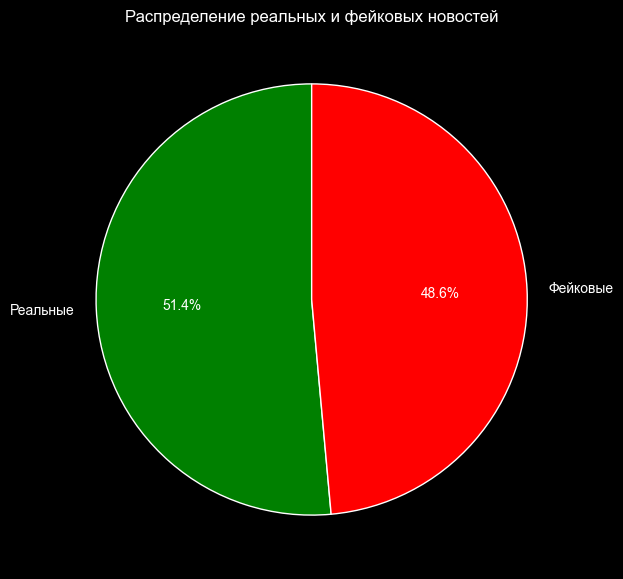

In [20]:
df_1 = datafake["label"].value_counts()

print(df_1)

plt.figure(figsize=(7, 7))
plt.pie(df_1,labels=['Реальные', 'Фейковые'],autopct="%1.1f%%",colors=['green', 'red'], startangle=90)
plt.title("Распределение реальных и фейковых новостей")

In [21]:
df_2 = datafake.copy()
df_2["text"] = datafake["text"].apply(lambda x: len(x))
df_2["title"] = datafake["title"].apply(lambda x: len(x))
df_2

,title,text,label
0,130,5049,1
1,0,46,1
2,137,216,1
3,105,8010,0
4,95,1916,1
...,...,...,...
72129,65,4788,0
72130,79,3634,1
72131,57,2864,0
72132,67,3374,0


Text(0, 0.5, 'Количество слов в тексте')

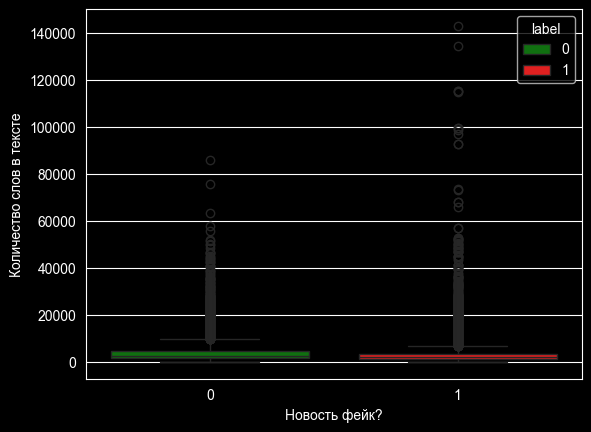

In [22]:
sns.boxplot(x="label", y="text", data=df_2, hue="label", palette=["green", "red"])
plt.xlabel("Новость фейк?")
plt.ylabel("Количество слов в тексте")

Text(0, 0.5, 'Количество слов в тексте')

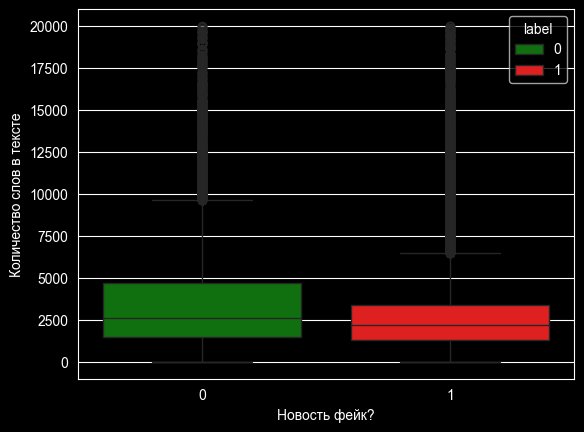

In [23]:
sns.boxplot(x="label", y="text", data=df_2[df_2["text"] < 20000], hue="label", palette=["green", "red"])
plt.xlabel("Новость фейк?")
plt.ylabel("Количество слов в тексте")

Проверим гипотезу о том, что чем у фейковых новостей в среднем меньше слов, чем у не фейковой

QQ-plot для длины текста

Text(0.5, 1.0, 'QQ-plot для распределения количества символов в тексте')

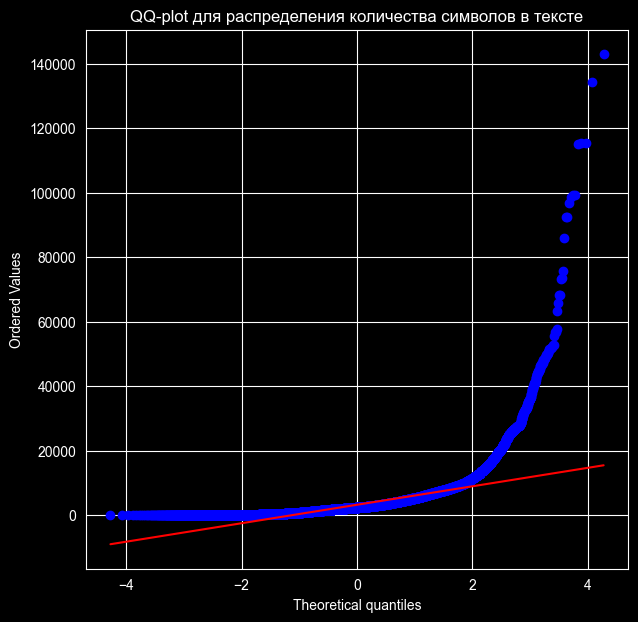

In [24]:
from scipy import stats

plt.figure(figsize=(7, 7))
stats.probplot(df_2["text"], dist="norm", plot=plt)
plt.title('QQ-plot для распределения количества символов в тексте')


Распределение не нормальное, следовательно используем тест Манна-Уитни

In [25]:
from scipy.stats import mannwhitneyu

alpha = 0.05

fake = df_2[df_2["label"] == 1]["text"]
real = df_2[df_2["label"] == 0]["text"]

statistic, p_value = mannwhitneyu(real,fake,alternative="greater")

print("Mann-Whitney U statistic:", statistic)
print("p-value:", p_value)



Mann-Whitney U statistic: 742939705.0
p-value: 2.301035726403793e-243


Получилось, что статистически значимо в реальных текстах в среднем больше символов, чем в фейковых. Это является основанием для нас добавить признак с длинной текста, для возможного улучшения точности ML модели

In [26]:
datafake["text_len"] = datafake["text"].apply(lambda x: len(x))
datafake

,title,text,label,text_len
0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...,1,5049
1,,Did they post their votes for Hillary already?,1,46
2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,"Now, most of the demonstrators gathered last ...",1,216
3,"Bobby Jindal, raised Hindu, uses story of Chri...",A dozen politically active pastors came here f...,0,8010
4,SATAN 2: Russia unvelis an image of its terrif...,"The RS-28 Sarmat missile, dubbed Satan 2, will...",1,1916
...,...,...,...,...
72129,Russians steal research on Trump in hack of U....,WASHINGTON (Reuters) - Hackers believed to be ...,0,4788
72130,WATCH: Giuliani Demands That Democrats Apolog...,"You know, because in fantasyland Republicans n...",1,3634
72131,Migrants Refuse To Leave Train At Refugee Camp...,Migrants Refuse To Leave Train At Refugee Camp...,0,2864
72132,Trump tussle gives unpopular Mexican leader mu...,MEXICO CITY (Reuters) - Donald Trump’s combati...,0,3374


## EDA для датасета с категориями

In [27]:
datacat

,link,headline,category,short_description,authors,date
0,https://www.huffpost.com/entry/covid-boosters-...,Over 4 Million Americans Roll Up Sleeves For O...,U.S. NEWS,Health experts said it is too early to predict...,"Carla K. Johnson, AP",2022-09-23
1,https://www.huffpost.com/entry/american-airlin...,"American Airlines Flyer Charged, Banned For Li...",U.S. NEWS,He was subdued by passengers and crew when he ...,Mary Papenfuss,2022-09-23
2,https://www.huffpost.com/entry/funniest-tweets...,23 Of The Funniest Tweets About Cats And Dogs ...,COMEDY,"""Until you have a dog you don't understand wha...",Elyse Wanshel,2022-09-23
3,https://www.huffpost.com/entry/funniest-parent...,The Funniest Tweets From Parents This Week (Se...,PARENTING,"""Accidentally put grown-up toothpaste on my to...",Caroline Bologna,2022-09-23
4,https://www.huffpost.com/entry/amy-cooper-lose...,Woman Who Called Cops On Black Bird-Watcher Lo...,U.S. NEWS,Amy Cooper accused investment firm Franklin Te...,Nina Golgowski,2022-09-22
...,...,...,...,...,...,...
209522,https://www.huffingtonpost.com/entry/rim-ceo-t...,RIM CEO Thorsten Heins' 'Significant' Plans Fo...,TECH,Verizon Wireless and AT&T are already promotin...,"Reuters, Reuters",2012-01-28
209523,https://www.huffingtonpost.com/entry/maria-sha...,Maria Sharapova Stunned By Victoria Azarenka I...,SPORTS,"Afterward, Azarenka, more effusive with the pr...",,2012-01-28
209524,https://www.huffingtonpost.com/entry/super-bow...,"Giants Over Patriots, Jets Over Colts Among M...",SPORTS,"Leading up to Super Bowl XLVI, the most talked...",,2012-01-28
209525,https://www.huffingtonpost.com/entry/aldon-smi...,Aldon Smith Arrested: 49ers Linebacker Busted ...,SPORTS,CORRECTION: An earlier version of this story i...,,2012-01-28


Удалим признаки "link", "authors", "date", т.к. они никак не помогут ML модели определять категорию текста

In [28]:
datacat = datacat.drop(columns=['link', "authors", "date"])
datacat

,headline,category,short_description
0,Over 4 Million Americans Roll Up Sleeves For O...,U.S. NEWS,Health experts said it is too early to predict...
1,"American Airlines Flyer Charged, Banned For Li...",U.S. NEWS,He was subdued by passengers and crew when he ...
2,23 Of The Funniest Tweets About Cats And Dogs ...,COMEDY,"""Until you have a dog you don't understand wha..."
3,The Funniest Tweets From Parents This Week (Se...,PARENTING,"""Accidentally put grown-up toothpaste on my to..."
4,Woman Who Called Cops On Black Bird-Watcher Lo...,U.S. NEWS,Amy Cooper accused investment firm Franklin Te...
...,...,...,...
209522,RIM CEO Thorsten Heins' 'Significant' Plans Fo...,TECH,Verizon Wireless and AT&T are already promotin...
209523,Maria Sharapova Stunned By Victoria Azarenka I...,SPORTS,"Afterward, Azarenka, more effusive with the pr..."
209524,"Giants Over Patriots, Jets Over Colts Among M...",SPORTS,"Leading up to Super Bowl XLVI, the most talked..."
209525,Aldon Smith Arrested: 49ers Linebacker Busted ...,SPORTS,CORRECTION: An earlier version of this story i...


Проверим пропуски

In [29]:
datacat.isna().sum()

headline             0
category             0
short_description    0
dtype: int64

Пропусков нет

Посмотрим на распределение категорий

In [45]:
temp = datacat["category"].value_counts(normalize=True).reset_index()
temp

,category,proportion
0,POLITICS,0.169916
1,WELLNESS,0.085645
2,ENTERTAINMENT,0.082863
3,TRAVEL,0.047249
4,STYLE & BEAUTY,0.046839
5,PARENTING,0.041956
6,HEALTHY LIVING,0.031948
7,QUEER VOICES,0.030292
8,FOOD & DRINK,0.030259
9,BUSINESS,0.028598


Text(0.5, 1.0, 'Распределение категорий новостей')

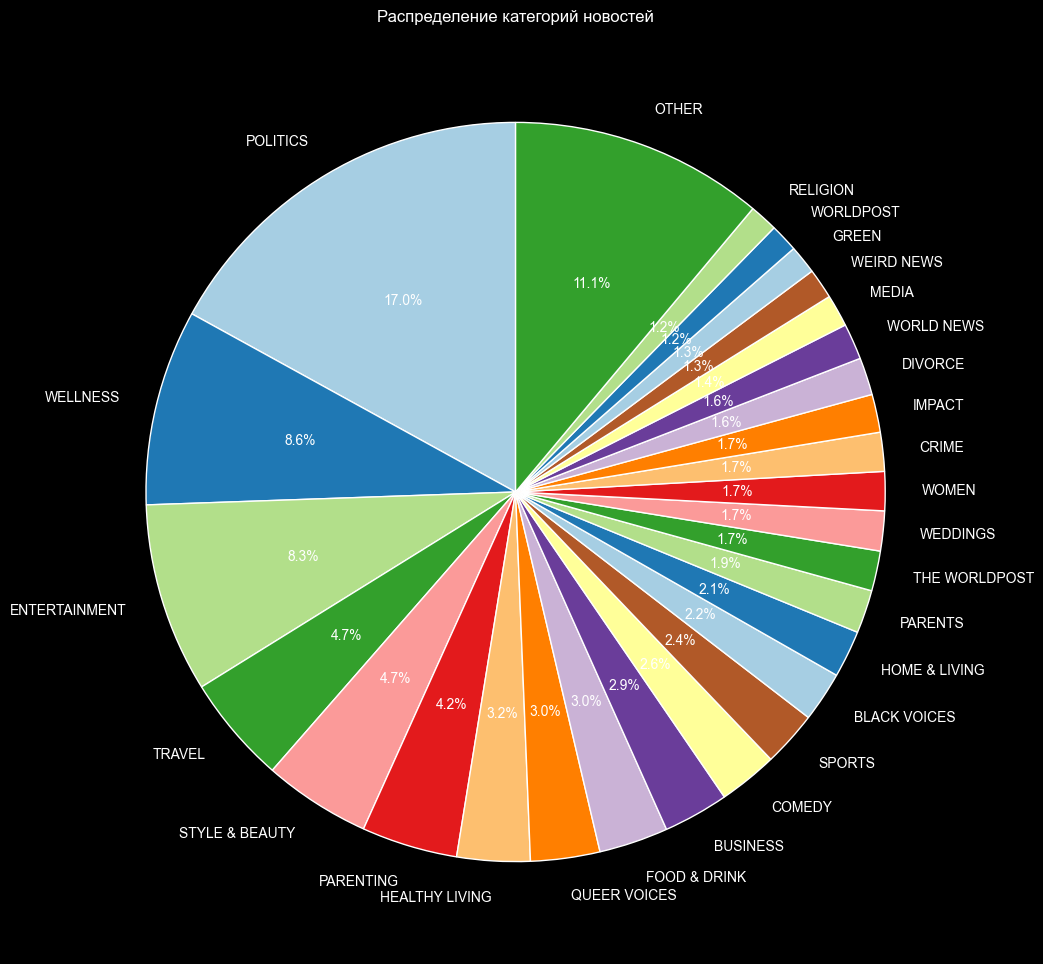

In [54]:
temp = datacat["category"].value_counts(normalize=True).reset_index()

temp = pd.concat([
    temp[temp["proportion"] > 0.011],
    pd.DataFrame({"category": ["OTHER"], "proportion": [temp[temp["proportion"] <= 0.011]["proportion"].sum()]})
])

plt.figure(figsize=(12, 12))
plt.pie(
    temp["proportion"],
    labels=temp["category"],
    autopct="%1.1f%%",
    startangle=90,
    colors= sns.color_palette("Paired", n_colors=len(temp["category"])),
)

plt.title("Распределение категорий новостей")


In [31]:
datafake.to_csv("datafake_cleaned.csv", index=False)

Сохранено: (72134, 4)
